In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

2026-04-12 07:00:42.645299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775977242.854347      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775977242.916424      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775977243.445721      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775977243.445754      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775977243.445758      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled")

GPU memory growth enabled


In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled")

Mixed precision enabled


In [4]:
#Paths
train_path = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/train/train'
test_path = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/test/test'

img_size=(128,128)
batch_size=32

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1.0/255.0,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    validation_split=0.2
)

train_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 21600 images belonging to 45 classes.
Found 5400 images belonging to 45 classes.


In [6]:
test_datagen=ImageDataGenerator(rescale=1.0/255.0)

test_generator=test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4500 images belonging to 45 classes.


In [7]:
#Verify everything
print("Classes:", len(train_generator.class_indices))
print(train_generator.class_indices)

print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Classes: 45
{'airplane': 0, 'airport': 1, 'baseball_diamond': 2, 'basketball_court': 3, 'beach': 4, 'bridge': 5, 'chaparral': 6, 'church': 7, 'circular_farmland': 8, 'cloud': 9, 'commercial_area': 10, 'dense_residential': 11, 'desert': 12, 'forest': 13, 'freeway': 14, 'golf_course': 15, 'ground_track_field': 16, 'harbor': 17, 'industrial_area': 18, 'intersection': 19, 'island': 20, 'lake': 21, 'meadow': 22, 'medium_residential': 23, 'mobile_home_park': 24, 'mountain': 25, 'overpass': 26, 'palace': 27, 'parking_lot': 28, 'railway': 29, 'railway_station': 30, 'rectangular_farmland': 31, 'river': 32, 'roundabout': 33, 'runway': 34, 'sea_ice': 35, 'ship': 36, 'snowberg': 37, 'sparse_residential': 38, 'stadium': 39, 'storage_tank': 40, 'tennis_court': 41, 'terrace': 42, 'thermal_power_station': 43, 'wetland': 44}
Train samples: 21600
Val samples: 5400
Test samples: 4500


In [8]:
#Now model building
model = Sequential([
    Input(shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.25),
    Dense(256, activation='relu'),
    Dropout(0.25),
    Dense(45, activation='softmax', dtype='float32')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1775977301.449095      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775977301.455271      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,922,349 (34.04 MB)

 Trainable params: 8,921,389 (34.03 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
#model trainig
history=model.fit(
    train_generator, validation_data=val_generator, epochs=50
)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 169s 250ms/step - accuracy: 0.1912 - loss: 2.9255 - val_accuracy: 0.1915 - val_loss: 3.0082
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 153s 227ms/step - accuracy: 0.2292 - loss: 2.7322 - val_accuracy: 0.2691 - val_loss: 2.6400
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 160s 237ms/step - accuracy: 0.2720 - loss: 2.5569 - val_accuracy: 0.3226 - val_loss: 2.3454
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 159s 236ms/step - accuracy: 0.3104 - loss: 2.4478 - val_accuracy: 0.2913 - val_loss: 2.5530
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 147s 219ms/step - accuracy: 0.3473 - loss: 2.2762 - val_accuracy: 0.3006 - val_loss: 2.5897
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 151s 223ms/step - accuracy: 0.3807 - loss: 2.1648 - val_accuracy: 0.4613 - val_loss: 1.8908
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 146s 216ms/step - accuracy: 0.4096 - loss: 2.0505 - val_accuracy: 0.3767 - val_loss: 2.5711
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 144s 214ms/step - accuracy: 0.4403 -

In [11]:
test_loss, test_accuracy=model.evaluate(test_generator)
print("Test accuracy: ", test_accuracy)

141/141 ━━━━━━━━━━━━━━━━━━━━ 46s 330ms/step - accuracy: 0.6884 - loss: 1.3454
Test accuracy:  0.7117778062820435


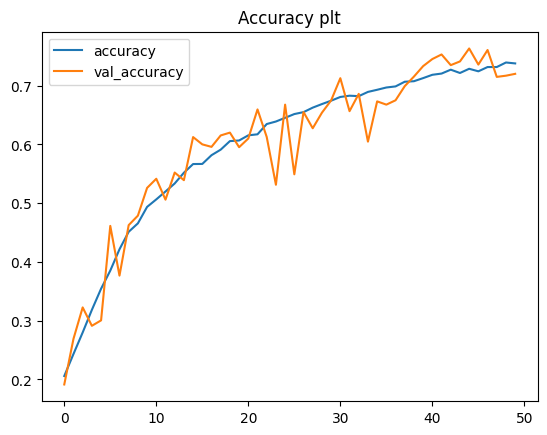

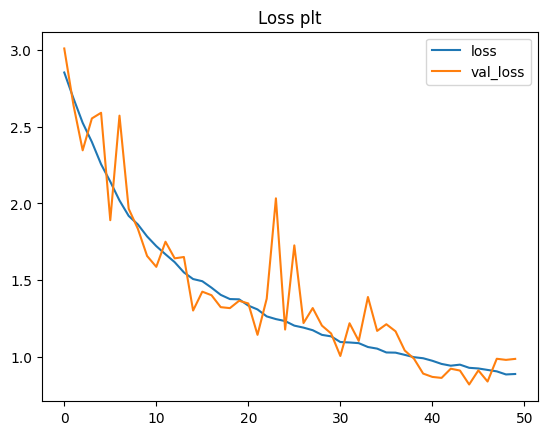

In [14]:
#plot loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy plt')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss plt')
plt.legend()
plt.show()

In [16]:
import os
import json
import numpy as np

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save the trained model (.keras format – recommended for TF2) ───────────
model_path = os.path.join(OUTPUT_DIR, 'cnn_resisc45.keras')
model.save(model_path)
print(f"Model saved → {model_path}")

# ── 2. Save class indices  {class_name: index} ────────────────────────────────
#    Also save the reverse map {index: class_name} – more useful at inference time
class_indices = train_generator.class_indices          # {'airplane': 0, ...}
idx_to_class  = {v: k for k, v in class_indices.items()}  # {0: 'airplane', ...}

with open(os.path.join(OUTPUT_DIR, 'class_indices.json'), 'w') as f:
    json.dump(class_indices, f, indent=2)

with open(os.path.join(OUTPUT_DIR, 'idx_to_class.json'), 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print(f"class_indices.json  ({len(class_indices)} classes)")
print(f"idx_to_class.json")

# ── 3. Save training history (for plots in Streamlit) ────────────────────────
history_dict = {
    'accuracy':     [float(v) for v in history.history['accuracy']],
    'val_accuracy': [float(v) for v in history.history['val_accuracy']],
    'loss':         [float(v) for v in history.history['loss']],
    'val_loss':     [float(v) for v in history.history['val_loss']],
}
with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history_dict, f, indent=2)
print("training_history.json")

# ── 4. Save model config / metadata ──────────────────────────────────────────
metadata = {
    'img_size':      [128, 128],
    'num_classes':   45,
    'batch_size':    batch_size,
    'test_accuracy': float(test_accuracy),
    'test_loss':     float(test_loss),
    'epochs_trained': len(history.history['accuracy']),
    'model_file':    'cnn_resisc45.keras',
}
with open(os.path.join(OUTPUT_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print("model_metadata.json")

# ── 5. Quick sanity-check: run one batch through the loaded model ─────────────
# ── 5. Quick sanity-check ─────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

loaded_model = load_model(model_path)
test_generator.reset()
sample_batch, _ = next(iter(test_generator))
preds = loaded_model.predict(sample_batch[:4], verbose=0)

print("\n Sanity check – top predictions on 4 test images:")
for i, pred in enumerate(preds):
    top3 = np.argsort(pred)[::-1][:3]
    print(f"  Image {i+1}: " + " | ".join(
        f"{idx_to_class[j]} ({pred[j]*100:.1f}%)" for j in top3   # ← int key, no str()
    ))

# ── Summary of saved files ────────────────────────────────────────────────────
print("\nFiles saved to", OUTPUT_DIR)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f"   {fname:35s}  {size_mb:6.2f} MB")

Model saved → /kaggle/working/cnn_resisc45.keras
class_indices.json  (45 classes)
idx_to_class.json
training_history.json
model_metadata.json

 Sanity check – top predictions on 4 test images:
  Image 1: airplane (99.9%) | runway (0.1%) | ship (0.0%)
  Image 2: airplane (100.0%) | parking_lot (0.0%) | runway (0.0%)
  Image 3: airport (29.2%) | railway_station (14.4%) | terrace (7.7%)
  Image 4: parking_lot (98.4%) | airplane (1.4%) | ship (0.1%)

Files saved to /kaggle/working
   .virtual_documents                     0.00 MB
   class_indices.json                     0.00 MB
   cnn_resisc45.keras                   178.54 MB
   idx_to_class.json                      0.00 MB
   model_metadata.json                    0.00 MB
   training_history.json                  0.00 MB


In [17]:
#Fine tune model (This code is copied from Claude)
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator

mixed_precision.set_global_policy('mixed_float16')

# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH  = '/kaggle/working/cnn_resisc45.keras'
OUTPUT_DIR  = '/kaggle/working'
train_path  = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/train/train'
test_path   = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/test/test'

IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32

# ── 1. Load the saved model ───────────────────────────────────────────────────
model = load_model(MODEL_PATH)
model.summary()

# ── 2. Freeze all layers first, then selectively unfreeze ────────────────────
#    Layer layout (from model.summary()):
#    0  conv2d          → freeze  (low-level edges)
#    1  batch_norm
#    2  max_pooling
#    3  conv2d_1        → freeze  (low-level textures)
#    4  batch_norm_1
#    5  max_pooling
#    6  conv2d_2        → UNFREEZE (mid-level patterns)
#    7  batch_norm_2
#    8  max_pooling
#    9  conv2d_3        → UNFREEZE (high-level semantics)
#    10 batch_norm_3
#    11 max_pooling
#    12 flatten
#    13 dense           → UNFREEZE
#    14 dropout
#    15 dense_1         → UNFREEZE
#    16 dropout_1
#    17 dense_2 (head)  → UNFREEZE

for layer in model.layers:
    layer.trainable = False

# Unfreeze from conv2d_2 onwards (last 2 conv blocks + dense head)
UNFREEZE_FROM = 'conv2d_2'
unfreeze = False
for layer in model.layers:
    if layer.name == UNFREEZE_FROM:
        unfreeze = True
    if unfreeze:
        # Keep BatchNorm frozen — avoids ruining learned stats with small batches
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

# Confirm what's trainable
print("\n── Layer trainability ──")
for layer in model.layers:
    print(f"  {layer.name:25s}  trainable={layer.trainable}")

# ── 3. Stronger augmentation for fine-tuning ─────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale            = 1.0/255.0,
    rotation_range     = 45,
    zoom_range         = 0.35,
    width_shift_range  = 0.25,
    height_shift_range = 0.25,
    brightness_range   = [0.6, 1.4],
    shear_range        = 0.2,
    channel_shift_range= 20.0,
    horizontal_flip    = True,
    vertical_flip      = True,       # aerial images → all orientations valid
    fill_mode          = 'reflect',
    validation_split   = 0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    shuffle      = True
)
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    shuffle      = False
)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False
)

# ── 4. Recompile with a much lower learning rate ──────────────────────────────
#    ~10–100x lower than original Adam default (0.001)
FINETUNE_LR = 1e-4

model.compile(
    optimizer = Adam(learning_rate=FINETUNE_LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── 5. Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        filepath          = os.path.join(OUTPUT_DIR, 'cnn_resisc45_finetuned_best.keras'),
        monitor           = 'val_accuracy',
        save_best_only    = True,
        mode              = 'max',
        verbose           = 1
    ),
    EarlyStopping(
        monitor           = 'val_accuracy',
        patience          = 8,           # stop if no improvement for 8 epochs
        restore_best_weights = True,
        verbose           = 1
    ),
    ReduceLROnPlateau(
        monitor           = 'val_loss',
        factor            = 0.5,         # halve LR on plateau
        patience          = 4,
        min_lr            = 1e-7,
        verbose           = 1
    ),
    CSVLogger(
        os.path.join(OUTPUT_DIR, 'finetune_log.csv'),
        append = False
    )
]

# ── 6. Fine-tune ──────────────────────────────────────────────────────────────
FINETUNE_EPOCHS = 30   # EarlyStopping will cut this short if needed

finetune_history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = FINETUNE_EPOCHS,
    callbacks       = callbacks
)

# ── 7. Evaluate ───────────────────────────────────────────────────────────────
test_generator.reset()
ft_loss, ft_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n Fine-tuned Test Accuracy : {ft_accuracy*100:.2f}%")
print(f" Fine-tuned Test Loss     : {ft_loss:.4f}")

# ── 8. Save everything ────────────────────────────────────────────────────────
# Final model
final_model_path = os.path.join(OUTPUT_DIR, 'cnn_resisc45_finetuned.keras')
model.save(final_model_path)
print(f"\n Final model → {final_model_path}")

# Updated training history (original + finetune concatenated)
with open(os.path.join(OUTPUT_DIR, 'training_history.json')) as f:
    original_history = json.load(f)

combined_history = {
    key: original_history[key] + [float(v) for v in finetune_history.history[key]]
    for key in ['accuracy', 'val_accuracy', 'loss', 'val_loss']
}
with open(os.path.join(OUTPUT_DIR, 'training_history_finetuned.json'), 'w') as f:
    json.dump(combined_history, f, indent=2)
print(" training_history_finetuned.json")

# Updated metadata
with open(os.path.join(OUTPUT_DIR, 'model_metadata.json')) as f:
    meta = json.load(f)

meta.update({
    'model_file'           : 'cnn_resisc45_finetuned.keras',
    'finetune_test_accuracy': float(ft_accuracy),
    'finetune_test_loss'   : float(ft_loss),
    'total_epochs'         : meta['epochs_trained'] + len(finetune_history.history['accuracy']),
    'finetune_lr'          : FINETUNE_LR,
})
with open(os.path.join(OUTPUT_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print(" model_metadata.json updated")

# ── 9. Output summary ─────────────────────────────────────────────────────────
print("\n Files in output:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1e6
    print(f"   {fname:45s} {size_mb:6.2f} MB")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,765,133 (102.10 MB)

 Trainable params: 8,921,389 (34.03 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 17,842,784 (68.06 MB)


── Layer trainability ──
  conv2d                     trainable=False
  batch_normalization        trainable=False
  max_pooling2d              trainable=False
  conv2d_1                   trainable=False
  batch_normalization_1      trainable=False
  max_pooling2d_1            trainable=False
  conv2d_2                   trainable=True
  batch_normalization_2      trainable=False
  max_pooling2d_2            trainable=True
  conv2d_3                   trainable=True
  batch_normalization_3      trainable=False
  max_pooling2d_3            trainable=True
  flatten                    trainable=True
  dense                      trainable=True
  dropout                    trainable=True
  dense_1                    trainable=True
  dropout_1                  trainable=True
  dense_2                    trainable=True
Found 21600 images belonging to 45 classes.
Found 5400 images belonging to 45 classes.
Found 4500 images belonging to 45 classes.
Epoch 1/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 1

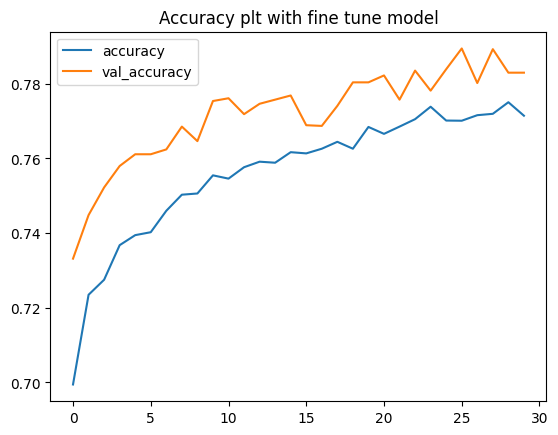

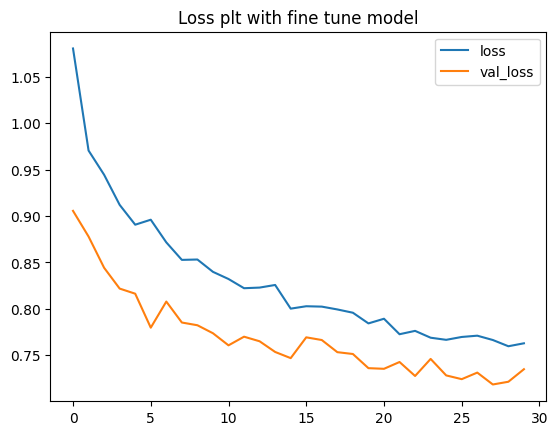

In [18]:
#plot loss and accuracy
import matplotlib.pyplot as plt
plt.plot(finetune_history.history['accuracy'], label='accuracy')
plt.plot(finetune_history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy plt with fine tune model')
plt.legend()
plt.show()

plt.plot(finetune_history.history['loss'], label='loss')
plt.plot(finetune_history.history['val_loss'], label='val_loss')
plt.title('Loss plt with fine tune model')
plt.legend()
plt.show()

## RestNet50V2

In [1]:
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, Conv2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-12 11:22:36.967403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775992957.369100      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775992957.483685      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775992958.715058      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775992958.715094      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775992958.715097      55 computation_placer.cc:177] computation placer alr

In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled")

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU memory growth enabled
Mixed precision enabled


In [4]:
train_path = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/train/train'
test_path = '/kaggle/input/datasets/aqibrehmanpirzada/nwpuresisc45/Dataset/test/test'

img_size = (224, 224)
batch_size=32

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [6]:
train_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator=test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 21600 images belonging to 45 classes.
Found 5400 images belonging to 45 classes.
Found 4500 images belonging to 45 classes.


In [7]:
#Verify everything
print("Classes:", len(train_generator.class_indices))
print(train_generator.class_indices)

print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Classes: 45
{'airplane': 0, 'airport': 1, 'baseball_diamond': 2, 'basketball_court': 3, 'beach': 4, 'bridge': 5, 'chaparral': 6, 'church': 7, 'circular_farmland': 8, 'cloud': 9, 'commercial_area': 10, 'dense_residential': 11, 'desert': 12, 'forest': 13, 'freeway': 14, 'golf_course': 15, 'ground_track_field': 16, 'harbor': 17, 'industrial_area': 18, 'intersection': 19, 'island': 20, 'lake': 21, 'meadow': 22, 'medium_residential': 23, 'mobile_home_park': 24, 'mountain': 25, 'overpass': 26, 'palace': 27, 'parking_lot': 28, 'railway': 29, 'railway_station': 30, 'rectangular_farmland': 31, 'river': 32, 'roundabout': 33, 'runway': 34, 'sea_ice': 35, 'ship': 36, 'snowberg': 37, 'sparse_residential': 38, 'stadium': 39, 'storage_tank': 40, 'tennis_court': 41, 'terrace': 42, 'thermal_power_station': 43, 'wetland': 44}
Train samples: 21600
Val samples: 5400
Test samples: 4500


In [8]:
import tensorflow as tf

base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(45, activation='softmax', dtype='float32')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss='categorical_crossentropy',
             metrics=['accuracy'])
model.summary()

I0000 00:00:1775993065.336134      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775993065.342376      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        23,085 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,636,973 (93.98 MB)

 Trainable params: 1,072,173 (4.09 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
history=model.fit(train_generator, validation_data=val_generator, epochs=30)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1775993098.148674     171 service.cc:152] XLA service 0x78c4100024a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775993098.148716     171 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775993098.148720     171 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775993100.029405     171 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/675 ━━━━━━━━━━━━━━━━━━━━ 3:18:59 18s/step - accuracy: 0.0000e+00 - loss: 5.0170

I0000 00:00:1775993108.324139     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/675 ━━━━━━━━━━━━━━━━━━━━ 5:07 562ms/step - accuracy: 0.0832 - loss: 3.9107